Carregando e processando dados...
Dados prontos! Iniciando treinamento dos modelos...

[1/2] Treinando KNN...
[2/2] Treinando Random Forest...

>> RESULTADOS DO KNN:
   Acurácia: 0.69 (Acertou 69% do total)
   Recall:   0.74 (Encontrou 74% das compras reais)
   F1-Score: 0.71 (Equilíbrio geral)
   AUC ROC:  0.76 (Qualidade da probabilidade)

>> RESULTADOS DO Random Forest:
   Acurácia: 0.70 (Acertou 70% do total)
   Recall:   0.79 (Encontrou 79% das compras reais)
   F1-Score: 0.73 (Equilíbrio geral)
   AUC ROC:  0.78 (Qualidade da probabilidade)


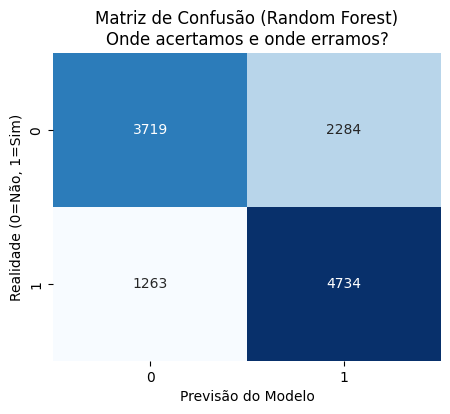

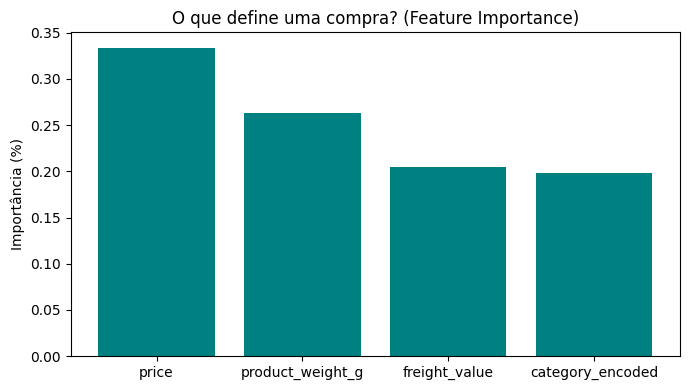

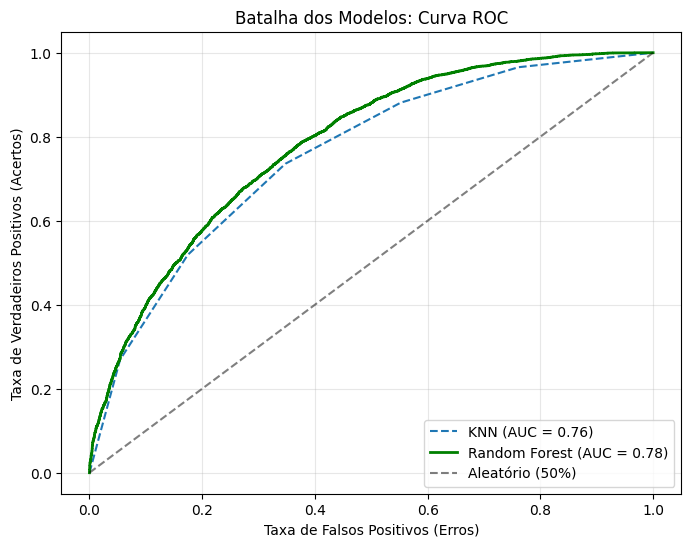


Análise concluída com sucesso! 🚀


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier 

# Accuracy: Nota geral.
# Precision: Quando chuta que é gol, acerta mesmo?
# Recall: De todos os gols possíveis, quantos ele viu?
# F1: Média entre Precision e Recall.
# ROC/AUC: Avalia a qualidade da probabilidade.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score


print("Carregando e processando dados...")

try:
    df_items = pd.read_csv('olist_order_items_dataset.csv')
    df_products = pd.read_csv('olist_products_dataset.csv')
except FileNotFoundError:
    print("ERRO CRÍTICO: Não achei os arquivos CSV. Verifique se eles estão na mesma pasta do código!")
    exit()

# Estamos juntando as duas tabelas. Queremos saber os detalhes (peso, categoria)
# de cada item que foi vendido. Usamos a coluna 'product_id' como chave.
df = df_items.merge(df_products, on='product_id', how='left')

# Selecionamos apenas as colunas que nosso modelo vai olhar.
# O resto (data, id do cliente, etc) jogamos fora para não confundir a máquina.
features = ['price', 'freight_value', 'product_weight_g', 'product_category_name']
df = df[features].dropna() # .dropna() remove linhas que tenham qualquer dado faltando (buracos).

# ==============================================================================
# 3. ESTRATÉGIA DE AMOSTRAGEM
# ==============================================================================
# O dataset original só tem vendas realizadas (Target = 1).
# Se ensinarmos só isso, a IA vai dizer "SIM" para tudo.
# Precisamos criar exemplos de "NÃO COMPRA" (Target = 0).

# --- PARTE A: O QUE É UMA COMPRA REAL? ---
# Pegamos 20.000 exemplos reais aleatórios da nossa tabela.
df_positive = df.sample(n=20000, random_state=42).copy()
df_positive['target'] = 1 #1 significa "Isso é uma compra válida".

# --- PARTE B: O QUE É UMA NÃO-COMPRA? (DADOS SINTÉTICOS) ---
# Como não temos dados de quem "olhou e não comprou", nós simulamos.
df_negative = df_positive.copy()
df_negative['price'] = df_negative['price'].sample(frac=1).values
df_negative['product_category_name'] = df_negative['product_category_name'].sample(frac=1).values
df_negative['target'] = 0 # Etiqueta: 0 significa "Isso é fake/não compra"

# Juntamos os positivos (reais) com os negativos (falsos/bagunçados).
# Agora temos 40.000 linhas balanceadas (metade sim, metade não).
df_final = pd.concat([df_positive, df_negative], axis=0)

# ==============================================================================
# 4. PRÉ-PROCESSAMENTO
# ==============================================================================

# Computador não lê texto ("Cama", "Banho"). Ele só lê números.
le_cat = LabelEncoder()
df_final['category_encoded'] = le_cat.fit_transform(df_final['product_category_name'])

# Definindo nossas variáveis:
# X = As perguntas da prova (Preço, Frete, Peso, Categoria).
# y = O gabarito da prova (0 ou 1).
X = df_final[['price', 'freight_value', 'product_weight_g', 'category_encoded']]
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- NORMALIZAÇÃO (Escalonamento) ---
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados prontos! Iniciando treinamento dos modelos...")

# ==============================================================================
# 5. TREINAMENTO DOS MODELOS (A IA "Aprendendo")
# ==============================================================================

# --- MODELO 1: KNN (K-Nearest Neighbors) ---
# n_neighbors=5: Ele olha os 5 vizinhos mais próximos. Se 3 forem "compra", ele chuta "compra".
# metric='euclidean': Usa uma régua simples (distância em linha reta) para medir proximidade.
print("\n[1/2] Treinando KNN...")
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

# Fazendo previsões:
# predict_proba: O modelo diz a chance (ex: "tenho 80% de certeza que é compra").
# predict: O modelo dá o veredito final (0 ou 1).
y_probs_knn = knn.predict_proba(X_test_scaled)[:, 1] # Pega a probabilidade de ser 1 (Compra)
y_pred_knn = knn.predict(X_test_scaled)

# --- MODELO 2: RANDOM FOREST (Floresta Aleatória) ---
# n_estimators=50: Criamos 50 árvores diferentes (um conselho de 50 especialistas).
# max_depth=10: Limitamos a profundidade para a árvore não "decorar" os dados (evita overfitting).
print("[2/2] Treinando Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train) # Treinamento (não usamos dados scaled aqui, pois árvores não precisam).

y_probs_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

# ==============================================================================
# 6. RESULTADOS E GRÁFICOS (A Hora da Verdade)
# ==============================================================================

# Função auxiliar para imprimir o boletim escolar da IA
def mostrar_resultado(nome, y_real, y_pred, y_prob):
    acc = accuracy_score(y_real, y_pred) # % de acertos totais
    rec = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)
    auc = roc_auc_score(y_real, y_prob)
    
    print(f"\n>> RESULTADOS DO {nome}:")
    print(f"   Acurácia: {acc:.2f} (Acertou {acc*100:.0f}% do total)")
    print(f"   Recall:   {rec:.2f} (Encontrou {rec*100:.0f}% das compras reais)")
    print(f"   F1-Score: {f1:.2f} (Equilíbrio geral)")
    print(f"   AUC ROC:  {auc:.2f} (Qualidade da probabilidade)")

# Mostra os números no terminal
mostrar_resultado("KNN", y_test, y_pred_knn, y_probs_knn)
mostrar_resultado("Random Forest", y_test, y_pred_rf, y_probs_rf)

# --- GRÁFICO 1: MATRIZ DE CONFUSÃO (Só do Random Forest, que é o campeão) ---
# Mostra: Verdadeiros Positivos, Falsos Positivos, etc.
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Random Forest)\nOnde acertamos e onde erramos?')
plt.ylabel('Realidade (0=Não, 1=Sim)')
plt.xlabel('Previsão do Modelo')
plt.show()

# --- GRÁFICO 2: IMPORTÂNCIA DAS VARIÁVEIS ---
# O Random Forest consegue nos dizer qual coluna ajudou mais ele a decidir.
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.title("O que define uma compra? (Feature Importance)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), X.columns[indices])
plt.ylabel('Importância (%)')
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: CURVA ROC COMPARATIVA ---
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_score(y_test, y_probs_knn):.2f})', linestyle='--')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_probs_rf):.2f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (50%)', alpha=0.5)

plt.xlabel('Taxa de Falsos Positivos (Erros)')
plt.ylabel('Taxa de Verdadeiros Positivos (Acertos)')
plt.title('Batalha dos Modelos: Curva ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("\nAnálise concluída com sucesso! 🚀")